## Analyze SSP585 (RCP8.5) drought data from the CMIP6 cloud storage:

Download data, plot it, save npy files to be later picked for students.

Data source: CMIP6 Zarr data residing in Pangeo's Google Storage

Variables:
* evspsbl — Evaporation incl. sublimation & transpiration (i.e., evapotranspiration). It’s the flux of water from the surface to the atmosphere, in kg m⁻² s⁻¹ 
* pr — Total precipitation (liquid + solid) to the surface, as a mass flux in kg m⁻² s⁻¹ (numerically equal to mm/s; multiply by 86 400 for mm/day). 
* mrso — Total soil moisture content: mass of water (all phases) per unit area summed over all soil layers, in kg m⁻².

Code mostly written by Joost van Asperen <joostvanasperen@college.harvard.edu> to read from cloud data instead of local data, replacing earlier code by Yonathan Vardi. Some edits by Eli.

In [1]:
import xarray as xr
import os
import numpy as np
import matplotlib.pyplot as plt
import intake
import time
import warnings

start_time = time.time()

# Global data tracking
total_data_size = 0  # in bytes

# -------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------
VARIABLES = ["evspsbl", "pr", "mrso"]
EXPERIMENTS_PRIMARY = ["historical", "ssp585"]
# ESM: with an active carbon cycle, CO2 is predicted, not prescribed:
# FALLBACK_EXPERIMENTS = {"historical": "esm-hist", "ssp585": "esm-ssp585"}
TABLE_MAP = {"evspsbl": "Amon", "pr": "Amon", "mrso": "Lmon"}
FACTOR = 31557.6  # conversion from kg/m²/s to mm/year

REGIONS = {
    "Sahel": {"lat": slice(10, 20), "lon": slice(345, 40)},
    "SW_US": {"lat": slice(32, 41), "lon": slice(235, 255)}
}

OUTPUT_DIR = "./Output/ssp585"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------------------------------------------------------------------
# Step 1: Discover available models
# -------------------------------------------------------------------
def discover_available_models():
    """
    Query the CMIP6 catalog to find all models with complete data
    for all required variables and experiments.
    """
    print("Discovering available models in CMIP6 catalog...")
    
    url = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
    col = intake.open_esm_datastore(url)
    
    # Filter for relevant data
    df = col.df[
        col.df["variable_id"].isin(VARIABLES) &
        col.df["experiment_id"].isin(EXPERIMENTS_PRIMARY) # + list(FALLBACK_EXPERIMENTS.values()))
    ]
    
    # Build model summary
    model_summary = {}
    for model in df["source_id"].unique():
        subset = df[df["source_id"] == model]
        model_summary[model] = {}
        for var in VARIABLES:
            exps = subset[subset["variable_id"] == var]["experiment_id"].unique().tolist()
            model_summary[model][var] = exps

    total_number_of_models=len(model_summary)
    
    # Check completeness
    available_models = []
    for model, vars_dict in model_summary.items():
        has_all = True
        for var in VARIABLES:
            exps = vars_dict.get(var, [])
            # Check for primary or fallback experiments
            # has_hist = ("historical" in exps) or (FALLBACK_EXPERIMENTS["historical"] in exps)
            # has_ssp = ("ssp585" in exps) or (FALLBACK_EXPERIMENTS["ssp585"] in exps)
            has_hist = ("historical" in exps) 
            has_ssp = ("ssp585" in exps)
            if not (has_hist and has_ssp):
                has_all = False
                print("Failed to find data for model ",model
                      ,", has_hist=",has_hist,", has_ssp=",has_ssp)
                break
        if has_all:
            available_models.append(model)
    
    available_models = sorted(available_models)
    print(f"✅ Found {len(available_models)} models with complete data out of"
          ,total_number_of_models,":")
    print(", ".join(available_models))
    print()
    
    return available_models

# -------------------------------------------------------------------
# Step 2: Load data from CMIP6 cloud
# -------------------------------------------------------------------
def open_cmip6_dataset(model, variable, experiment):
    """
    Open CMIP6 dataset from Google Cloud via intake-esm.
    Automatically falls back to esm-hist/esm-ssp585 if primary not available.
    If multiple ensemble members exist, select the first.
    """
    global total_data_size
    
    url = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
    col = intake.open_esm_datastore(url)
    
    query = dict(
        experiment_id=experiment,
        variable_id=variable,
        table_id=TABLE_MAP[variable],
        source_id=model
    )
    
    #dsets = col.search(**query).to_dataset_dict(zarr_kwargs={"consolidated": True})
    dsets = col.search(**query).to_dataset_dict(
        zarr_kwargs={"consolidated": True},
        xarray_open_kwargs={"decode_times": True, "use_cftime": True},
    )
    
    # Fallback logic
    # if not dsets and experiment in FALLBACK_EXPERIMENTS:
    #     fallback = FALLBACK_EXPERIMENTS[experiment]
    #     print(f"  → Fallback: using '{fallback}' instead of '{experiment}'")
    #     query["experiment_id"] = fallback
    #     dsets = col.search(**query).to_dataset_dict(zarr_kwargs={"consolidated": True})
    
    if not dsets:
        raise ValueError(f"No data found for {model} {variable} {experiment}")
    
    # Select first dataset (first ensemble member if multiple exist)
    key = list(dsets.keys())[0]
    ds = dsets[key]
    
    if "member_id" in ds.dims or "member_id" in ds.coords:
        first_member = ds["member_id"].values[0]
        print(f"  → Using ensemble member: {first_member}")
        ds = ds.sel(member_id=first_member)
    
    da = ds[variable]
    
    # Track data size
    data_size = da.nbytes
    total_data_size += data_size
    
    # Apply conversion factor for flux variables
    if variable in ["evspsbl", "pr"]:
        da = da * FACTOR
    
    return da


def load_model_data(model):
    """
    Load all required variables and experiments for a single model.
    Returns dict with variables and inferred start year.
    If any (variable, experiment) fails to load, abort the model entirely.
    """
    print(f"\n{'='*60}")
    print(f"Loading model: {model}")
    print(f"{'='*60}")
    
    model_data = {}
    min_year = None
    
    for var in VARIABLES:
        print(f"  Variable: {var}")
        all_experiments = []
        
        for exp in EXPERIMENTS_PRIMARY:
            try:
                da = open_cmip6_dataset(model, var, exp)
                da = da.load()
                all_experiments.append(da)
                
                # Track earliest year
                year = int(da["time"].dt.year.values[0])
                if min_year is None or year < min_year:
                    min_year = year
                    
            except Exception as e:
                # Abort the whole model on first failure so nothing will be saved later.
                print(f"  ⚠ Warning: could not load {exp} — {e}")
                print(f"  ✗ Aborting model '{model}' due to incomplete data")
                return None  # <-- ensures main() skips processing/saving for this model
        
        if all_experiments:
            # Concatenate, sort, and deduplicate time
            da_concat = xr.concat(all_experiments, dim="time")
            da_concat = da_concat.sortby("time")
            _, index = np.unique(da_concat["time"], return_index=True)
            da_concat = da_concat.isel(time=index)
            
            model_data[var] = da_concat
            print(f"  ✓ Loaded {var}: {len(da_concat.time)} time steps")
        else:
            print(f"  ✗ Failed to load {var}")
            return None
    
    model_data["start_year"] = min_year
    print(f"  Start year: {min_year}")
    
    return model_data


# -------------------------------------------------------------------
# Step 3: Process data (yearly averages, regional subsets, smoothing)
# -------------------------------------------------------------------
def compute_yearly_averages(data):
    """Resample monthly data to yearly means."""
    yearly = {}
    for var_key, da in data.items():
        if var_key != "start_year":
            yearly[var_key] = da.resample(time="YS").mean()
    yearly["start_year"] = data["start_year"]
    return yearly

def subset_region(da, region):
    """
    Slice a DataArray by latitude and longitude, handling longitude wrap-around.
    """
    da_region = da.sel(lat=region["lat"])
    lon_min, lon_max = region["lon"].start, region["lon"].stop
    lons = da_region["lon"].values
    
    # Convert longitudes to 0–360 if necessary
    if np.any(lons < 0):
        lons = np.where(lons < 0, lons + 360, lons)
        da_region = da_region.assign_coords(lon=lons)
    
    if lon_min > lon_max:
        da_region = da_region.where(
            (da_region.lon >= lon_min) | (da_region.lon <= lon_max), 
            drop=True
        )
    else:
        da_region = da_region.sel(lon=slice(lon_min, lon_max))
    
    return da_region

def area_weighted_mean(da):
    """
    Compute area-weighted mean over latitude and longitude.
    Latitude weighting by cos(latitude).
    """
    weights = np.cos(np.deg2rad(da["lat"]))
    weights = weights / weights.mean()
    result = da.weighted(weights).mean(dim=("lat", "lon"))
    return result.compute().squeeze()

def smooth_two_pass(values):
    """
    Apply a 1-2-1 smoothing filter twice to a 1D array.
    Returns the array trimmed by 2 points at both ends.
    """
    data_smooth = np.copy(values)
    for _ in range(2):
        temp = np.copy(data_smooth)
        for j in range(1, len(values) - 1):
            temp[j] = 0.25 * data_smooth[j-1] + 0.5 * data_smooth[j] + 0.25 * data_smooth[j+1]
        data_smooth = temp
    return data_smooth[2:-2]

def process_and_save_model(model, model_data):
    """
    Process a single model: compute yearly averages, regional means,
    smooth, and save to disk.
    """
    print(f"\nProcessing {model}...")
    
    # Yearly averages
    yearly = compute_yearly_averages(model_data)
    start_year = yearly["start_year"]
    
    # Regional subsets and means
    for var_key in VARIABLES:
        da = yearly[var_key]
        
        for region_name, region_bounds in REGIONS.items():
            # Subset region
            da_region = subset_region(da, region_bounds)
            
            # Compute area-weighted mean
            da_mean = area_weighted_mean(da_region)
            
            # Smooth and save
            values = da_mean.values
            years = np.arange(start_year, start_year + len(values))
            
            if len(values) > 4:  # Need at least 5 points to smooth
                smoothed_values = smooth_two_pass(values)
                smoothed_years = years[2:-2]
                smoothed_series = np.array([smoothed_years, smoothed_values])
                
                filename = f"{model.lower()}_{var_key}_{region_name.lower()}.npy"
                save_path = os.path.join(OUTPUT_DIR, filename)
                np.save(save_path, smoothed_series)
                print(f"  ✓ Saved {filename}")
            else:
                print(f"  ⚠ Skipping {var_key}/{region_name}: insufficient data for smoothing")

# -------------------------------------------------------------------
# Main execution
# -------------------------------------------------------------------
def main():
    # Discover available models
    available_models = discover_available_models()
    
    if not available_models:
        print("❌ No models found with complete data. Exiting.")
        return
    
    # Process each model
    successful = 0
    failed = []
    
    for i, model in enumerate(available_models, 1):
        print(f"\n{'#'*60}")
        print(f"Model {i}/{len(available_models)}: {model}")
        print(f"{'#'*60}")
        
        try:
            # Load data
            model_data = load_model_data(model)
            
            if model_data is None:
                print(f"⚠ Skipping {model}: incomplete data")
                failed.append(model)
                continue
            
            # Process and save
            process_and_save_model(model, model_data)
            successful += 1
            
        except Exception as e:
            print(f"❌ Error processing {model}: {e}")
            failed.append(model)
            continue
    
    # Summary
    print(f"\n{'='*60}")
    print(f"PROCESSING COMPLETE")
    print(f"{'='*60}")
    print(f"✅ Successfully processed: {successful}/{len(available_models)} models")
    if failed:
        print(f"❌ Failed models: {', '.join(failed)}")
    
    # Format data size
    data_gb = total_data_size / (1024**3)
    data_tb = total_data_size / (1024**4)
    if data_tb >= 1:
        print(f"📊 Total data processed: {data_tb:.2f} TB ({data_gb:.2f} GB)")
    else:
        print(f"📊 Total data processed: {data_gb:.2f} GB")
    
    end_time = time.time()
    elapsed_minutes = (end_time - start_time) / 60
    print(f"⏱  Total elapsed time: {elapsed_minutes:.2f} minutes ({end_time - start_time:.2f} seconds)")
    print(f"📁 Output saved to: {OUTPUT_DIR}")

if __name__ == "__main__":
    main()

Discovering available models in CMIP6 catalog...
Failed to find data for model  BCC-ESM1 , has_hist= True , has_ssp= False
Failed to find data for model  SAM0-UNICON , has_hist= True , has_ssp= False
Failed to find data for model  GISS-E2-1-H , has_hist= True , has_ssp= False
Failed to find data for model  AWI-CM-1-1-MR , has_hist= False , has_ssp= False
Failed to find data for model  MPI-ESM-1-2-HAM , has_hist= True , has_ssp= False
Failed to find data for model  NESM3 , has_hist= False , has_ssp= False
Failed to find data for model  CAMS-CSM1-0 , has_hist= False , has_ssp= False
Failed to find data for model  E3SM-1-0 , has_hist= True , has_ssp= False
Failed to find data for model  GISS-E2-1-G-CC , has_hist= True , has_ssp= False
Failed to find data for model  FGOALS-g3 , has_hist= False , has_ssp= False
Failed to find data for model  MIROC-ES2L , has_hist= True , has_ssp= False
Failed to find data for model  KACE-1-0-G , has_hist= False , has_ssp= False
Failed to find data for model

  → Using ensemble member: r1i1p1f1

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


  → Using ensemble member: r1i1p1f1
  ✓ Loaded evspsbl: 5412 time steps
  Variable: pr

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


  → Using ensemble member: r1i1p1f1

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


  → Using ensemble member: r1i1p1f1
  ✓ Loaded pr: 5412 time steps
  Variable: mrso

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


...

  → Using ensemble member: r1i1p1f2
  ✓ Loaded evspsbl: 3012 time steps
  Variable: pr

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


  → Using ensemble member: r13i1p1f2

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


  → Using ensemble member: r1i1p1f2
  ✓ Loaded pr: 5412 time steps
  Variable: mrso

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


  → Using ensemble member: r13i1p1f2

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


  → Using ensemble member: r1i1p1f2
  ✓ Loaded mrso: 3012 time steps
  Start year: 1850

Processing UKESM1-0-LL...
  ✓ Saved ukesm1-0-ll_evspsbl_sahel.npy
  ✓ Saved ukesm1-0-ll_evspsbl_sw_us.npy
  ✓ Saved ukesm1-0-ll_pr_sahel.npy
  ✓ Saved ukesm1-0-ll_pr_sw_us.npy
  ✓ Saved ukesm1-0-ll_mrso_sahel.npy
  ✓ Saved ukesm1-0-ll_mrso_sw_us.npy

PROCESSING COMPLETE
✅ Successfully processed: 22/34 models
❌ Failed models: ACCESS-ESM1-5, CESM2, CMCC-ESM2, CNRM-CM6-1, EC-Earth3, EC-Earth3-CC, EC-Earth3-Veg, EC-Earth3-Veg-LR, GFDL-ESM4, MCM-UA-1-0, MIROC6, NorESM2-LM
📊 Total data processed: 51.67 GB
⏱  Total elapsed time: 99.81 minutes (5988.89 seconds)
📁 Output saved to: ./Output/ssp585


## Now plot:


Available models:
1: access-cm2
2: bcc-csm2-mr
3: canesm5
4: canesm5-canoe
5: cesm2-waccm
6: cmcc-cm2-sr5
7: cnrm-cm6-1-hr
8: cnrm-esm2-1
9: fgoals-f3-l
10: gfdl-cm4
11: giss-e2-1-g
12: hadgem3-gc31-ll
13: hadgem3-gc31-mm
14: inm-cm4-8
15: inm-cm5-0
16: ipsl-cm6a-lr
17: mpi-esm1-2-hr
18: mpi-esm1-2-lr
19: mri-esm2-0
20: noresm2-mm
21: taiesm1
22: ukesm1-0-ll

Total models: 22
Selecting models in script, not interactively.

Selected models (2): ['gfdl-cm4', 'hadgem3-gc31-ll']

Figure saved to: ./Output/ssp585/multimodel_soil_moisture.pdf


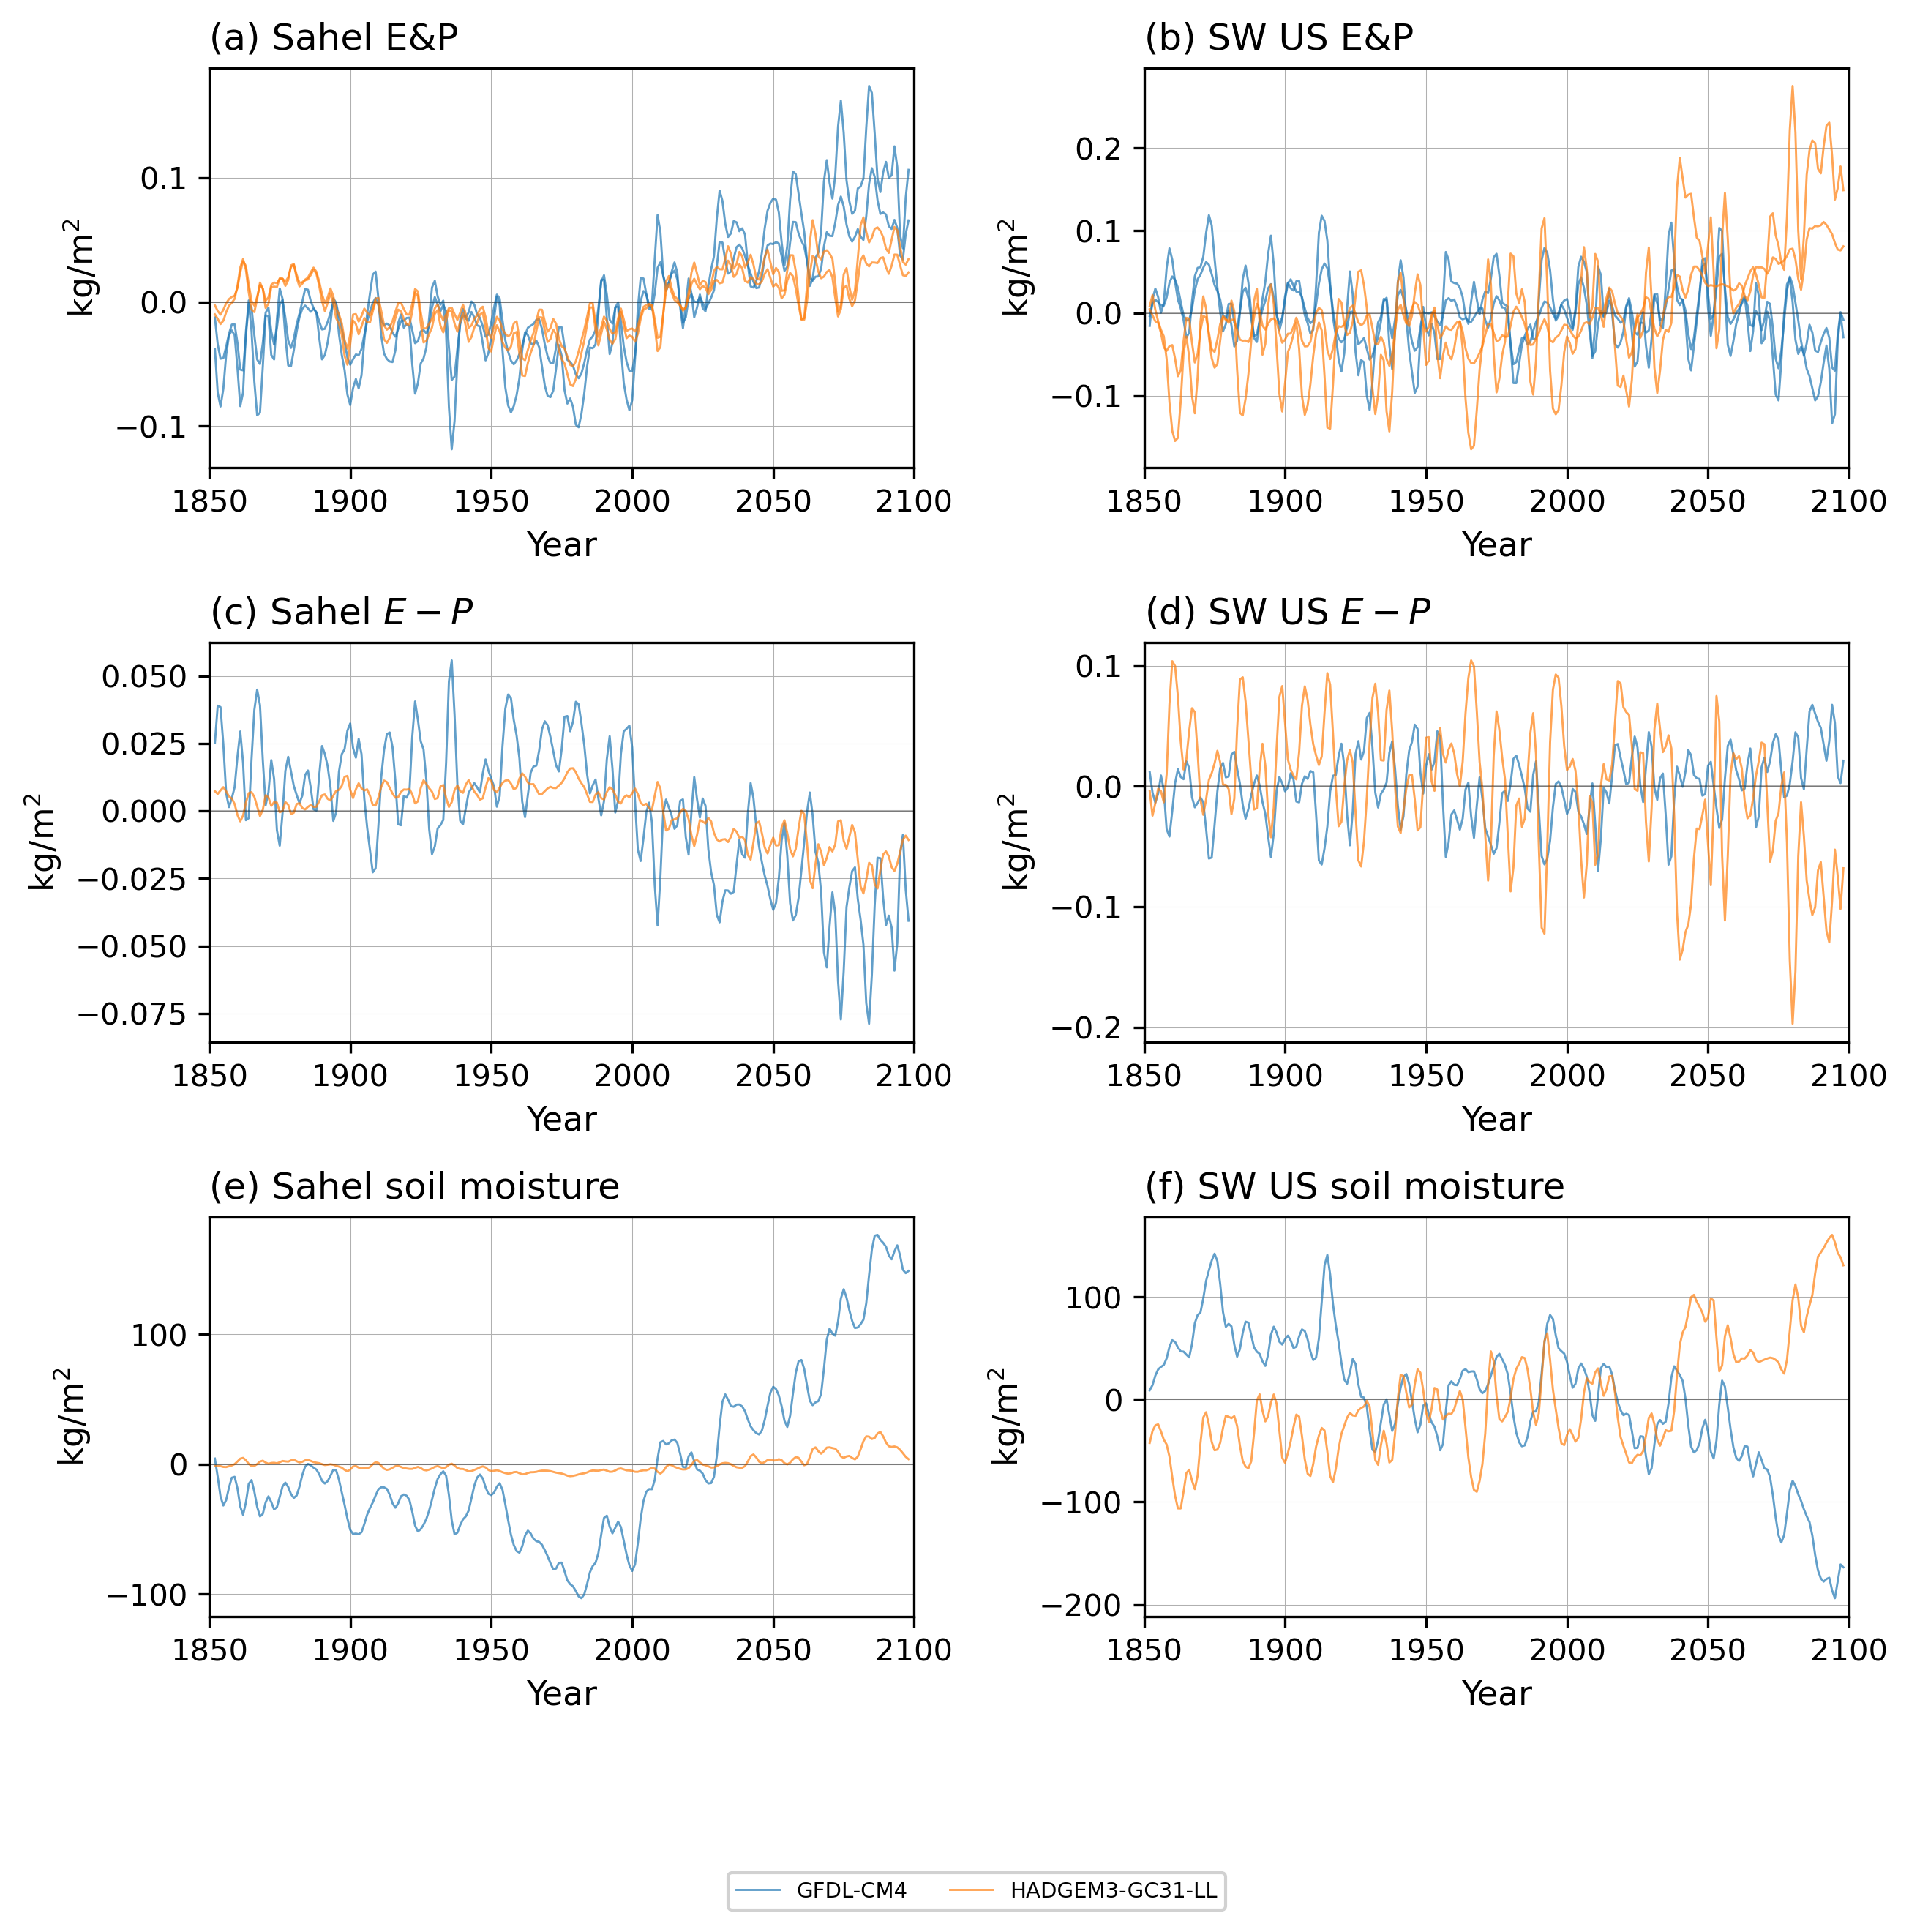

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from itertools import product

OUTPUT_DIR = "./Output/ssp585"
regions = ["sahel", "sw_us"]
VARIABLES = ["evspsbl", "pr", "mrso"]
MAX_YEAR = 2098

def clip_to_year(years, series, max_year=MAX_YEAR):
    m = years <= max_year
    return years[m], series[m]

# -------------------------------------------------------------------
# Load all available model data
# -------------------------------------------------------------------
def load_all_models(region, variable):
    pattern = os.path.join(OUTPUT_DIR, f"*_{variable}_{region}.npy")
    files = sorted(glob(pattern))
    models = {}    
    for filepath in files:
        filename = os.path.basename(filepath)
        model_name = filename.replace(f"_{variable}_{region}.npy", "")
        try:
            data = np.load(filepath)
            models[model_name] = data[()]
        except Exception as e:
            print(f"Warning: Could not load {filename}: {e}")
    return models

# -------------------------------------------------------------------
# Prompt for model selection
# -------------------------------------------------------------------
def select_models(models_dict):
    all_models = sorted(models_dict.keys())
    print("\nAvailable models:")
    for i, m in enumerate(all_models, start=1):
        print(f"{i}: {m}")
    print(f"\nTotal models: {len(all_models)}")

    selection = None
    print("Selecting models in script, not interactively.")
    # Uncomment this to be able to selected models interactively.
    #selection = input("Enter model numbers separated by commas (or Enter for 10,12, or 0 to select all): ").strip()

    if not selection:
        selection = '10,12'
    if selection == '0':
        return all_models
    else:
        selected_models = []
        for s in selection.split(","):
            try:
                idx = int(s) - 1
                if 0 <= idx < len(all_models):
                    selected_models.append(all_models[idx])
            except:
                pass
        return selected_models

# -------------------------------------------------------------------
# Load all model data
# -------------------------------------------------------------------
all_models_data=[{},{},{}]
ivar = 0
for variable in VARIABLES:
    all_models_data[ivar] = {region: load_all_models(region, variable) for region in regions}
    ivar = ivar + 1

# Select models once for all regions
selected_models = select_models(all_models_data[0]["sahel"])
Nselected_models = len(selected_models)
print(f"\nSelected models ({len(selected_models)}): {selected_models}")
selected_models_data=[{},{},{}]
ivar = 0
for variable in VARIABLES:
    # Filter selected models per region
    selected_models_data[ivar] = {
        region: {k: v for k, v in all_models_data[ivar][region].items() if k in selected_models}
        for region in regions
    }
    ivar = ivar + 1

# -------------------------------------------------------------------
# Assign unique color + linestyle combinations
# -------------------------------------------------------------------
# ten colors + three linestyles gives 30 combinations; 28 total models, so enough coverage
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(10)]

linestyles = ['-', '--', '-.']

all_combinations = []

for linestyle in linestyles:
    for color in colors:
        all_combinations.append({'color': color, 'linestyle': linestyle})

# Assign one combination per model
model_styles = {}
for i, model_name in enumerate(sorted(selected_models)):
    model_styles[model_name] = all_combinations[i]


# -------------------------------------------------------------------
# Plotting
# -------------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(10, 8), dpi=300)

legend_handles = []
legend_labels = []

region_titles = {
    "sahel": "(a) Sahel E&P",
    "sw_us": "(b) SW US E&P"
}

for ax, region in zip(axes[0,0:2], regions):
    
    # E, P, Soil moisture: ["evspsbl", "pr", "mrso"]
    E=selected_models_data[0][region]
    P=selected_models_data[1][region]
    Soil_moisture=selected_models_data[2][region]

    imodel = 0
    for model_name, data in sorted(selected_models_data[0][region].items()):

        years_evspsbl = E[model_name][0, :]
        evspsbl = E[model_name][1, :]
        evspsbl = evspsbl - np.mean(evspsbl)
        years_pr = P[model_name][0, :]
        pr = P[model_name][1, :]
        pr = pr - np.mean(pr)

        if Nselected_models == 2:
            # save for students
            filename="Output/%s_model%1d_evaporation.npy" % (region,imodel)
            np.save(filename,[years_evspsbl,evspsbl])
            filename="Output/%s_model%1d_precipitation.npy" % (region,imodel)
            np.save(filename,[years_pr,pr])

        style = model_styles[model_name]
        color = style['color']
        linestyle = style['linestyle']

        line1, = ax.plot(years_evspsbl, evspsbl, lw=0.7, alpha=0.7,
                        color=color, linestyle=linestyle,
                        label=model_name.upper())
        line2, = ax.plot(years_pr, pr, lw=0.7, alpha=0.7,
                        color=color, linestyle=linestyle,
                        label=model_name.upper())

        imodel = imodel + 1

    ax.set_ylabel("kg/m$^2$", fontsize=11)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_title(region_titles[region], loc="left", fontsize=12)
    ax.set_xlim([1850, 2100])
    ax.grid(lw=0.25)
    ax.axhline(y=0, color='black', lw=0.5, linestyle='-', alpha=0.3)



region_titles = {
    "sahel": "(c) Sahel $E-P$",
    "sw_us": "(d) SW US $E-P$"
}

for ax, region in zip(axes[1,0:2], regions):
    
    # E, P, Soil moisture: ["evspsbl", "pr", "mrso"]
    E=selected_models_data[0][region]
    P=selected_models_data[1][region]
    Soil_moisture=selected_models_data[2][region]

    for model_name, data in sorted(selected_models_data[1][region].items()):

        years_evspsbl = E[model_name][0, :]
        evspsbl = E[model_name][1, :]
        years_evspsbl, evspsbl = clip_to_year(years_evspsbl, evspsbl)
        evspsbl = evspsbl - np.mean(evspsbl)
        
        years_pr = P[model_name][0, :]
        pr = P[model_name][1, :]
        years_pr, pr = clip_to_year(years_pr, pr)
        pr = pr - np.mean(pr)
        
        if len(years_evspsbl) != len(years_pr):
            print("*** incompatible length of E and P records:",len(years_evspsbl), len(years_pr))
            print("model_name=",model_name,", region=",region)
            print("max years_evspsbl=",max(years_evspsbl)
                  ,", max years_pr=",max(years_pr))
        else:
            style = model_styles[model_name]
            line, = ax.plot(years_evspsbl, evspsbl-pr, lw=0.7, alpha=0.7,
                    color=style['color'], linestyle=style['linestyle'],
                    label=model_name.upper())

    
    ax.set_ylabel("kg/m$^2$", fontsize=11)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_title(region_titles[region], loc="left", fontsize=12)
    ax.set_xlim([1850, 2100])
    ax.grid(lw=0.25)
    ax.axhline(y=0, color='black', lw=0.5, linestyle='-', alpha=0.3)

region_titles = {
    "sahel": "(e) Sahel soil moisture",
    "sw_us": "(f) SW US soil moisture"
}

for ax, region in zip(axes[2,0:2], regions):
    
    # E, P, Soil moisture: ["evspsbl", "pr", "mrso"]
    E=selected_models_data[0][region]
    P=selected_models_data[1][region]
    Soil_moisture=selected_models_data[2][region]

    imodel = 0
    for model_name, data in sorted(selected_models_data[2][region].items()):

        years_mrso = Soil_moisture[model_name][0, :]
        mrso = Soil_moisture[model_name][1, :]
        mrso = mrso - np.mean(mrso)
        
        if Nselected_models == 2:
            # save for students
            filename="Output/%s_model%1d_moisture.npy" % (region,imodel)
            np.save(filename,[years_mrso,mrso])

        style = model_styles[model_name]
        line, = ax.plot(years_mrso, mrso, lw=0.7, alpha=0.7,
                        color=style['color'], linestyle=style['linestyle'],
                        label=model_name.upper())

        # Only add legend handles from first region
        if region == regions[0]:
            legend_handles.append(line)
            legend_labels.append(model_name.upper())

        imodel = imodel + 1

    ax.set_ylabel("kg/m$^2$", fontsize=11)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_title(region_titles[region], loc="left", fontsize=12)
    ax.set_xlim([1850, 2100])
    ax.grid(lw=0.25)
    ax.axhline(y=0, color='black', lw=0.5, linestyle='-', alpha=0.3)

# Single legend outside the plots
fig.legend(
    legend_handles, legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.45, -0.10),
    fontsize=7,
    framealpha=0.9,
    ncol=6
)

plt.tight_layout(rect=[0,0,0.88,1])  # leave space for legend

# Save figure
output_path = os.path.join(OUTPUT_DIR, "multimodel_soil_moisture.pdf")
fig.savefig(output_path, format='pdf', bbox_inches='tight')
print(f"\nFigure saved to: {output_path}")

plt.show()
